# 07 - Paper-style precipitation downscaling pipeline (Khulna)

This notebook **replaces the old workflow from Notebook 07 onward** and is designed to run after your preprocessing/alignment work (Notebooks 00-06).

It follows the output structure of the reference paper as closely as your Khulna datasets allow:

- correct month-matched station training table (fixes the 808-column leakage/problem in the old station extraction table),
- paper-style input combinations (`Comb1`, `Comb2`, `Comb3`, with/without land variables),
- Cubist, Random Forest, XGBoost, LightGBM and CatBoost (Cubist is optional if the package is unavailable),
- **MAE, RMSE and PCC** comparison table similar to Table 1,
- downscaled monthly and annual precipitation maps similar to Fig. 2,
- station-wise spatial MAE/RMSE/PCC maps similar to Figs. 3-5,
- SHAP summary + mean-|SHAP| feature-importance panels similar to Figs. 6-8,
- observed-vs-predicted plot and export of all figures/tables.

> Important: the paper uses 2016 as an independent test year and 2017-2021 for model development. Your repository contains aligned rasters for 2017-2022, so the default here is **train 2017-2020, validation 2021, test 2022**. Change the three year settings below if you add other years.

In [1]:
# OPTIONAL: run once if these packages are not already installed.
# Uncomment the next line only when needed.
# %pip install -q xgboost lightgbm catboost shap cubist geopandas joblib


In [2]:
from __future__ import annotations

from pathlib import Path
from collections import OrderedDict
import re, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from pyproj import Transformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestRegressor
import joblib

# -----------------------------
# Project paths
# -----------------------------
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "configs").exists():
            return candidate
    raise FileNotFoundError("Project root not found. Run this notebook from inside the repository.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
ALIGNED_ROOT = PROCESSED_DIR / "aligned_rasters"
PRECIP_ROOT = ALIGNED_ROOT / "precipitation"
PRED_ROOT = ALIGNED_ROOT / "predictors"
MODEL_DIR = PROJECT_ROOT / "models" / "paper_style"
OUT_ROOT = PROJECT_ROOT / "outputs" / "paper_style"
TABLE_DIR = OUT_ROOT / "tables"
FIG_DIR = OUT_ROOT / "figures"
MAP_DIR = OUT_ROOT / "maps"
for p in [MODEL_DIR, TABLE_DIR, FIG_DIR, MAP_DIR]: p.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Temporal split (adapted to your available 2017-2022 data)
# -----------------------------
TRAIN_YEARS = [2017, 2018, 2019, 2020]
VALID_YEARS = [2021]
TEST_YEARS  = [2022]

# Run-time controls
FAST_MODE = True          # True = smaller parameter grids; False = more paper-like tuning
MAX_SHAP_SAMPLES = 400
RANDOM_STATE = 42
NODATA_SENTINELS = (-9999, -9999.0, -3.4e38)

print("Project root:", PROJECT_ROOT)
print("Aligned precipitation:", PRECIP_ROOT)
print("Aligned predictors:", PRED_ROOT)


Project root: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh
Aligned precipitation: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\data\processed\aligned_rasters\precipitation
Aligned predictors: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\data\processed\aligned_rasters\predictors


## 1. Discover datasets and standardize product names

The alignment notebook shows these precipitation datasets in your project: CCS, CDR, CHIRPS, ERA5, GSMaP Gauge, GSMaP MVK, IMERG, PDIR and PERSIANN. This cell auto-detects whichever folders are actually present.

In [3]:
def norm_name(text: str) -> str:
    return re.sub(r"[^A-Z0-9]+", "_", text.upper()).strip("_")

ALIASES = {
    "CHIRPS_TIFF_2017_2022": "CHIRPS",
    "ERA5_TIFF": "ERA5",
    "IMERG_MONTHLY": "IMERG",
    "GSMAP_GAUGE_V7": "GSMAP_GAUGE",
    "GSMAP_MVK": "GSMAP_MVK",
    "PERSIANN": "PERSIANN",
    "CDR": "CDR",
    "CCS": "CCS",
    "PDIR": "PDIR",
}

def canonical_dataset(folder_name: str) -> str:
    n = norm_name(folder_name)
    return ALIASES.get(n, n)

def list_tifs(folder: Path):
    out=[]
    for pat in ("*.tif","*.tiff","*.TIF","*.TIFF"):
        out += list(folder.glob(pat))
    return sorted(set(out))

precip_folders = {canonical_dataset(p.name): p for p in PRECIP_ROOT.iterdir() if p.is_dir()} if PRECIP_ROOT.exists() else {}
predictor_folders = {canonical_dataset(p.name): p for p in PRED_ROOT.iterdir() if p.is_dir()} if PRED_ROOT.exists() else {}

print("Precipitation products:", sorted(precip_folders))
print("Predictor folders:", sorted(predictor_folders))

if not precip_folders:
    raise FileNotFoundError("No aligned precipitation folders found under data/processed/aligned_rasters/precipitation")


Precipitation products: ['CCS', 'CDR', 'CHIRPS', 'ERA5', 'GSMAP_GAUGE', 'GSMAP_MVK', 'IMERG', 'PDIR', 'PERSIANN']
Predictor folders: ['ASPECT', 'DEM', 'DISTANCE_SEA', 'LST_DAY', 'NDVI', 'SLOPE']


## 2. File matching helpers

Monthly files are matched using the year/month contained in their filenames. Static layers use the first valid raster in their folder.

In [4]:
YEAR_MONTH_RE = re.compile(r"(?<!\d)(20\d{2})[_-](0?[1-9]|1[0-2])(?!\d)")

def index_monthly(folder: Path):
    idx={}
    for p in list_tifs(folder):
        m = YEAR_MONTH_RE.search(p.stem)
        if m:
            idx[(int(m.group(1)), int(m.group(2)))] = p
    return idx

precip_index = {name:index_monthly(folder) for name,folder in precip_folders.items()}
predictor_index = {name:index_monthly(folder) for name,folder in predictor_folders.items()}

# Land variables corresponding to the paper; extras are allowed.
LAND_ORDER = ["DEM", "SLOPE", "ASPECT", "DISTANCE_SEA", "NDVI", "LST_DAY"]
land_available = [x for x in LAND_ORDER if x in predictor_folders]
print("Land features used:", land_available)

static_land = {name: list_tifs(predictor_folders[name])[0]
               for name in land_available
               if name not in {"NDVI", "LST_DAY"} and list_tifs(predictor_folders[name])}

def monthly_path(dataset: str, year: int, month: int):
    if dataset in precip_index:
        return precip_index[dataset].get((year,month))
    if dataset in predictor_index:
        return predictor_index[dataset].get((year,month))
    return None

def read_value_at_lonlat(path: Path, lon: float, lat: float) -> float:
    with rasterio.open(path) as src:
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        x,y = transformer.transform(float(lon), float(lat))
        val = float(next(src.sample([(x,y)]))[0])
        if src.nodata is not None and np.isclose(val, src.nodata, equal_nan=True): return np.nan
        if any(np.isclose(val, v, equal_nan=True) for v in NODATA_SENTINELS): return np.nan
        if not np.isfinite(val): return np.nan
        return val


Land features used: ['DEM', 'SLOPE', 'ASPECT', 'DISTANCE_SEA', 'NDVI', 'LST_DAY']


## 3. Build a **correct month-matched modelling table**

This is the key correction. The old Notebook 06 produced one row with hundreds of columns such as `CCS_2017_01`, `CCS_2017_02`, ..., even though a row itself belongs to only one year-month. That leaks information across time and makes later modelling incorrect.

Here each station-month row receives only the raster value for **that same year and month**, plus static land variables.

In [5]:
gauge_path = PROCESSED_DIR / "station_samples" / "gauge_monthly_clean.csv"
if not gauge_path.exists():
    raise FileNotFoundError(f"Missing {gauge_path}. Run your gauge preprocessing first.")

gauge = pd.read_csv(gauge_path)
needed = {"latitude","longitude","year","month"}
if not needed.issubset(gauge.columns):
    raise ValueError(f"Gauge table must contain {needed}")

target_candidates = ["rainfall_mm","rainfall","precipitation","precip_mm"]
TARGET = next((c for c in target_candidates if c in gauge.columns), None)
if TARGET is None: raise ValueError("Rainfall target column not found in gauge_monthly_clean.csv")

rows=[]
for i,row in gauge.iterrows():
    y,m = int(row.year), int(row.month)
    rec = row.to_dict()
    # monthly precipitation products
    for name in sorted(precip_folders):
        p = monthly_path(name,y,m)
        rec[name] = read_value_at_lonlat(p,row.longitude,row.latitude) if p else np.nan
    # monthly land variables
    for name in ["NDVI","LST_DAY"]:
        if name in predictor_folders:
            p = monthly_path(name,y,m)
            rec[name] = read_value_at_lonlat(p,row.longitude,row.latitude) if p else np.nan
    # static land variables
    for name,p in static_land.items():
        rec[name] = read_value_at_lonlat(p,row.longitude,row.latitude)
    rows.append(rec)

data = pd.DataFrame(rows)
feature_candidates = sorted(precip_folders) + land_available
for c in feature_candidates:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")
        data.loc[data[c] < -1000, c] = np.nan

data = data.sort_values(["year","month","station_id" if "station_id" in data.columns else "latitude"]).reset_index(drop=True)
out = PROCESSED_DIR / "station_samples" / "station_monthly_features_corrected.csv"
data.to_csv(out,index=False)

print("Saved:", out)
print("Shape:", data.shape)
display(data[[c for c in ["station_id","station","year","month",TARGET] if c in data.columns] + feature_candidates].head(12))
display(data[feature_candidates].isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame())


Saved: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\data\processed\station_samples\station_monthly_features_corrected.csv
Shape: (432, 23)


,station_id,station,year,month,rainfall_mm,CCS,CDR,CHIRPS,ERA5,GSMAP_GAUGE,GSMAP_MVK,IMERG,PDIR,PERSIANN,DEM,SLOPE,ASPECT,DISTANCE_SEA,NDVI,LST_DAY
0,CL503,Chalna,2017,1,0.0,0.401950,NaN,4.387781,0.278754,0.000000,1.765300,0.000000,10.467163,NaN,3.491428,1.720395,307.573151,31.578037,0.3041,23.280001
1,CL504,Dumuria,2017,1,0.0,1.000000,5.447627,3.775759,0.424140,0.000000,3.242605,0.001000,12.070197,0.048504,5.504085,1.932987,15.174459,57.437077,0.4520,22.764999
2,CL509,Kapilmuni,2017,1,0.0,NaN,4.464538,3.364661,NaN,0.000000,3.273617,0.001000,NaN,0.000000,4.366783,NaN,245.235504,NaN,0.3265,22.815001
3,CL510,Khulna,2017,1,0.0,1.000000,6.215549,4.313319,0.409056,0.000000,2.501563,0.000019,11.374859,0.260531,6.754479,2.105171,270.000000,55.997879,0.3783,24.895000
4,CL515,Paikgacha,2017,1,0.0,0.625072,4.270297,4.934360,0.370125,0.000000,2.566727,0.001000,4.497904,0.000000,4.656047,1.600269,180.000000,37.843204,0.2905,23.049999
5,CL517,Rupsa,2017,1,0.0,1.000000,6.369730,5.610559,0.367366,0.000000,1.893955,0.000277,12.297443,0.326694,3.710326,1.544958,227.325211,51.649570,0.3680,23.170000
6,CL503,Chalna,2017,2,0.0,0.000000,NaN,5.731336,3.280216,0.522361,0.000000,0.003135,0.000000,NaN,3.491428,1.720395,307.573151,31.578037,0.3495,27.740000
7,CL504,Dumuria,2017,2,0.0,0.000000,0.000000,5.261413,2.834512,0.456497,2.186530,0.002374,0.000000,0.000000,5.504085,1.932987,15.174459,57.437077,0.5674,26.540001
8,CL509,Kapilmuni,2017,2,0.0,NaN,0.000000,6.110463,NaN,0.577834,0.578232,0.004614,NaN,0.000000,4.366783,NaN,245.235504,NaN,0.4192,26.424999
9,CL510,Khulna,2017,2,0.0,0.000000,0.000000,5.011328,3.353448,0.934495,6.169003,0.002985,0.000000,0.000000,6.754479,2.105171,270.000000,55.997879,0.3812,29.075001


,missing_fraction
CCS,0.166667
CDR,0.166667
ERA5,0.166667
DISTANCE_SEA,0.166667
SLOPE,0.166667
PERSIANN,0.166667
PDIR,0.166667
LST_DAY,0.134259
GSMAP_MVK,0.069444
CHIRPS,0.000000


## 4. Define paper-style combinations

- `Comb1`: all available precipitation products.
- `Comb2`: long-record products used in the paper (CHIRPS, CDR/PERSIANN-CDR, ERA5), when present.
- `Comb3`: near-real-time products (CCS and PDIR), when present.
- `_land`: adds available land-surface features.
- Individual `product_land` combinations are also evaluated, producing a Table-1-style comparison.

In [6]:
precip_products = sorted([c for c in precip_folders if c in data.columns])
land_features = [c for c in LAND_ORDER if c in data.columns]

long_term_pref = ["CHIRPS","CDR","PERSIANN","ERA5"]
nrt_pref = ["CCS","PDIR"]
comb2_base = [c for c in long_term_pref if c in precip_products]
comb3_base = [c for c in nrt_pref if c in precip_products]

COMBINATIONS = OrderedDict()
COMBINATIONS["Comb1"] = precip_products
COMBINATIONS["Comb1_land"] = precip_products + land_features
if comb2_base:
    COMBINATIONS["Comb2"] = comb2_base
    COMBINATIONS["Comb2_land"] = comb2_base + land_features
if comb3_base:
    COMBINATIONS["Comb3"] = comb3_base
    COMBINATIONS["Comb3_land"] = comb3_base + land_features
for p in precip_products:
    COMBINATIONS[f"{p}_land"] = [p] + land_features

# remove duplicates while preserving order
for k,v in list(COMBINATIONS.items()):
    COMBINATIONS[k] = list(dict.fromkeys(v))

combo_table = pd.DataFrame({"combination":COMBINATIONS.keys(), "features":[", ".join(v) for v in COMBINATIONS.values()]})
display(combo_table)
combo_table.to_csv(TABLE_DIR / "input_combinations.csv", index=False)


,combination,features
0,Comb1,"CCS, CDR, CHIRPS, ERA5, GSMAP_GAUGE, GSMAP_MVK..."
1,Comb1_land,"CCS, CDR, CHIRPS, ERA5, GSMAP_GAUGE, GSMAP_MVK..."
2,Comb2,"CHIRPS, CDR, PERSIANN, ERA5"
3,Comb2_land,"CHIRPS, CDR, PERSIANN, ERA5, DEM, SLOPE, ASPEC..."
4,Comb3,"CCS, PDIR"
5,Comb3_land,"CCS, PDIR, DEM, SLOPE, ASPECT, DISTANCE_SEA, N..."
6,CCS_land,"CCS, DEM, SLOPE, ASPECT, DISTANCE_SEA, NDVI, L..."
7,CDR_land,"CDR, DEM, SLOPE, ASPECT, DISTANCE_SEA, NDVI, L..."
8,CHIRPS_land,"CHIRPS, DEM, SLOPE, ASPECT, DISTANCE_SEA, NDVI..."
9,ERA5_land,"ERA5, DEM, SLOPE, ASPECT, DISTANCE_SEA, NDVI, ..."


## 5. Models and temporal validation

The paper tunes models on training/validation data and evaluates on a temporally independent test year. This notebook follows that logic rather than random train/test splitting.

In [7]:
# Optional ML packages
AVAILABLE = {}
try:
    from xgboost import XGBRegressor
    AVAILABLE["XGBoost"] = True
except Exception as e:
    AVAILABLE["XGBoost"] = False; print("XGBoost unavailable:", e)
try:
    from lightgbm import LGBMRegressor
    AVAILABLE["LightGBM"] = True
except Exception as e:
    AVAILABLE["LightGBM"] = False; print("LightGBM unavailable:", e)
try:
    from catboost import CatBoostRegressor
    AVAILABLE["CatBoost"] = True
except Exception as e:
    AVAILABLE["CatBoost"] = False; print("CatBoost unavailable:", e)
try:
    from cubist import Cubist
    AVAILABLE["Cubist"] = True
except Exception as e:
    AVAILABLE["Cubist"] = False; print("Cubist unavailable (install `cubist` to include it):", e)

MODELS = OrderedDict()
if AVAILABLE.get("Cubist"):
    MODELS["Cubist"] = (Cubist, {"n_committees":[5,10] if FAST_MODE else [1,5,10,20], "neighbors":[0,3] if FAST_MODE else [0,3,5,9]})
MODELS["Random Forest"] = (RandomForestRegressor, {
    "n_estimators":[300] if FAST_MODE else [200,400,700],
    "max_depth":[None,15] if FAST_MODE else [None,8,15,25],
    "min_samples_leaf":[1,2] if FAST_MODE else [1,2,4],
    "max_features":["sqrt",1.0],
})
if AVAILABLE.get("XGBoost"):
    MODELS["XGBoost"] = (XGBRegressor, {
        "n_estimators":[300] if FAST_MODE else [200,400,700],
        "max_depth":[3,6] if FAST_MODE else [3,5,7],
        "learning_rate":[0.05,0.1],
        "subsample":[0.8,1.0],
    })
if AVAILABLE.get("LightGBM"):
    MODELS["LightGBM"] = (LGBMRegressor, {
        "n_estimators":[300] if FAST_MODE else [200,400,700],
        "num_leaves":[15,31] if FAST_MODE else [15,31,63],
        "learning_rate":[0.05,0.1],
        "max_depth":[-1,10],
    })
if AVAILABLE.get("CatBoost"):
    MODELS["CatBoost"] = (CatBoostRegressor, {
        "iterations":[300] if FAST_MODE else [250,500,800],
        "depth":[4,7] if FAST_MODE else [4,6,8],
        "learning_rate":[0.05,0.1],
    })

print("Models that will run:", list(MODELS))


Cubist unavailable (install `cubist` to include it): No module named 'cubist'
Models that will run: ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']


In [8]:
def pcc(y_true, y_pred):
    a=np.asarray(y_true,float); b=np.asarray(y_pred,float)
    mask=np.isfinite(a)&np.isfinite(b)
    if mask.sum()<2 or np.nanstd(a[mask])==0 or np.nanstd(b[mask])==0: return np.nan
    return float(np.corrcoef(a[mask],b[mask])[0,1])

def metrics(y_true,y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true,y_pred)),
        "RMSE": float(mean_squared_error(y_true,y_pred)**0.5),
        "PCC": pcc(y_true,y_pred),
    }

def make_estimator(name, cls, params):
    base=dict(params)
    if name=="Random Forest": base.update(random_state=RANDOM_STATE,n_jobs=-1)
    elif name=="XGBoost": base.update(random_state=RANDOM_STATE,n_jobs=-1,objective="reg:squarederror")
    elif name=="LightGBM": base.update(random_state=RANDOM_STATE,verbosity=-1)
    elif name=="CatBoost": base.update(random_seed=RANDOM_STATE,verbose=False,loss_function="RMSE")
    elif name=="Cubist": pass
    return cls(**base)

def temporal_fit(combo, features, model_name, cls, grid):
    d=data[[TARGET,"year"]+features].copy()
    d=d[np.isfinite(pd.to_numeric(d[TARGET],errors="coerce"))]
    tr=d.year.isin(TRAIN_YEARS); va=d.year.isin(VALID_YEARS); te=d.year.isin(TEST_YEARS)
    if tr.sum()==0 or te.sum()==0:
        raise ValueError(f"Missing train/test rows for {combo}. Check TRAIN_YEARS/TEST_YEARS.")
    Xtr=d.loc[tr,features].replace([np.inf,-np.inf],np.nan); ytr=d.loc[tr,TARGET]
    Xva=d.loc[va,features].replace([np.inf,-np.inf],np.nan); yva=d.loc[va,TARGET]
    Xte=d.loc[te,features].replace([np.inf,-np.inf],np.nan); yte=d.loc[te,TARGET]
    imp=SimpleImputer(strategy="median")
    Xtr_i=imp.fit_transform(Xtr)
    Xva_i=imp.transform(Xva) if len(Xva) else None
    best=None; best_score=np.inf
    for params in ParameterGrid(grid):
        est=make_estimator(model_name,cls,params)
        est.fit(Xtr_i,ytr)
        if len(Xva):
            score=mean_squared_error(yva,est.predict(Xva_i))**0.5
        else:
            score=mean_squared_error(ytr,est.predict(Xtr_i))**0.5
        if score<best_score: best_score=score; best=(params,est)
    params,_=best
    # retrain on train + validation using the selected hyperparameters
    dev=tr|va
    Xdev=d.loc[dev,features].replace([np.inf,-np.inf],np.nan); ydev=d.loc[dev,TARGET]
    imp=SimpleImputer(strategy="median")
    Xdev_i=imp.fit_transform(Xdev)
    est=make_estimator(model_name,cls,params); est.fit(Xdev_i,ydev)
    pred=np.maximum(est.predict(imp.transform(Xte)),0)
    return {"imputer":imp,"estimator":est,"features":features,"params":params,"test_index":d.index[te],"y_test":yte.to_numpy(),"pred_test":pred}


## 6. Train all combinations and create the Table-1-style metrics table

In [9]:
trained={}; records=[]
for combo,features in COMBINATIONS.items():
    usable=[f for f in features if f in data.columns and data[f].notna().any()]
    if not usable: continue
    print(f"\n=== {combo}: {len(usable)} features ===")
    for model_name,(cls,grid) in MODELS.items():
        try:
            bundle=temporal_fit(combo,usable,model_name,cls,grid)
            trained[(combo,model_name)]=bundle
            m=metrics(bundle["y_test"],bundle["pred_test"])
            records.append({"Input":combo,"Model":model_name,**m,"BestParams":json.dumps(bundle["params"],default=str)})
            print(model_name,m)
        except Exception as e:
            print("SKIP",model_name,"->",e)

results_long=pd.DataFrame(records)
results_long.to_csv(TABLE_DIR/"table1_metrics_long.csv",index=False)

# paper-like wide layout: MAE/RMSE/PCC under every model
paper_table=results_long.pivot(index="Input",columns="Model",values=["MAE","RMSE","PCC"])
# reorder columns by model, then metric
ordered=[]
for model in MODELS:
    for metric in ["MAE","RMSE","PCC"]:
        if (metric,model) in paper_table.columns: ordered.append((metric,model))
paper_table=paper_table[ordered]
paper_table.columns=pd.MultiIndex.from_tuples([(m,metric) for metric,m in paper_table.columns],names=["Model","Metric"])
paper_table=paper_table.round({c:2 if c[1] != "PCC" else 3 for c in paper_table.columns})
paper_table.to_csv(TABLE_DIR/"Table_1_paper_style_metrics.csv")
display(paper_table)



=== Comb1: 9 features ===
Random Forest {'MAE': 67.7638066821296, 'RMSE': 93.56641582937911, 'PCC': 0.7348915036226005}
XGBoost {'MAE': 68.09762834542327, 'RMSE': 92.23280600551755, 'PCC': 0.7477222165226768}
LightGBM {'MAE': 68.90344781974437, 'RMSE': 98.01070981633116, 'PCC': 0.712042314355544}
CatBoost {'MAE': 65.53248323616873, 'RMSE': 88.0870495963557, 'PCC': 0.7647010513042237}

=== Comb1_land: 15 features ===
Random Forest {'MAE': 62.82331287251845, 'RMSE': 90.38879584147834, 'PCC': 0.7558584281396823}
XGBoost {'MAE': 60.86449029048284, 'RMSE': 90.41409922383221, 'PCC': 0.7571625167014149}
LightGBM {'MAE': 65.999516043478, 'RMSE': 97.04719973771711, 'PCC': 0.7089693108402002}
CatBoost {'MAE': 56.80515408148269, 'RMSE': 84.22348356308864, 'PCC': 0.8053411839024808}

=== Comb2: 4 features ===
Random Forest {'MAE': 65.47680896003011, 'RMSE': 93.70932218782484, 'PCC': 0.749455204758569}
XGBoost {'MAE': 62.67226666212082, 'RMSE': 91.62663990164273, 'PCC': 0.7690141034575496}
LightGB

Model            Random Forest                XGBoost                LightGBM  \
Metric                     MAE    RMSE    PCC     MAE    RMSE    PCC      MAE   
Input                                                                           
CCS_land                 61.91   98.12  0.709   75.32  115.32  0.591    68.93   
CDR_land                 61.92   95.20  0.715   88.64  135.32  0.545    71.29   
CHIRPS_land              59.06   91.37  0.743   69.72  104.64  0.675    66.42   
Comb1                    67.76   93.57  0.735   68.10   92.23  0.748    68.90   
Comb1_land               62.82   90.39  0.756   60.86   90.41  0.757    66.00   
Comb2                    65.48   93.71  0.749   62.67   91.63  0.769    68.78   
Comb2_land               55.80   88.63  0.770   63.55   95.44  0.733    63.16   
Comb3                    77.55  106.48  0.622   82.69  111.49  0.603    80.58   
Comb3_land               63.55   97.35  0.708   73.85  106.82  0.638    75.00   
ERA5_land                56.72   85.24  0.768   65.76   94.84  0.711    62.28   
GSMAP_GAUGE_land         57.92   91.11  0.764   62.14   95.51  0.764    64.41   
GSMAP_MVK_land           58.86   99.54  0.706   76.65  118.38  0.554    69.73   
IMERG_land               56.78   87.15  0.764   66.53   97.49  0.707    70.69   
PDIR_land                63.15   91.27  0.729   74.55  108.02  0.638    69.28   
PERSIANN_land            70.15  111.76  0.607   81.57  128.41  0.498    78.14   

Model                           CatBoost                 
Metric              RMSE    PCC      MAE    RMSE    PCC  
Input                                                    
CCS_land          103.50  0.667    74.04  105.95  0.638  
CDR_land          110.26  0.653    70.39  105.60  0.662  
CHIRPS_land       102.51  0.687    58.00   92.16  0.751  
Comb1              98.01  0.712    65.53   88.09  0.765  
Comb1_land         97.05  0.709    56.81   84.22  0.805  
Comb2             100.48  0.717    63.98   93.49  0.753  
Comb2_land         92.11  0.747    54.53   87.82  0.770  
Comb3             107.74  0.638    77.04  102.13  0.659  
Comb3_land        107.18  0.657    70.25  102.40  0.664  
ERA5_land          97.88  0.695    56.75   84.13  0.776  
GSMAP_GAUGE_land   98.85  0.736    61.03   95.91  0.749  
GSMAP_MVK_land    113.94  0.605    63.79  101.42  0.681  
IMERG_land        106.29  0.651    59.88   89.73  0.761  
PDIR_land         102.56  0.681    68.46   97.26  0.697  
PERSIANN_land     122.01  0.551    74.54  111.92  0.617

## 7. Generate downscaled rasters for the independent test year

Each month is predicted on the aligned high-resolution grid. Output rasters are saved by combination/model/month.

In [10]:
def raster_array(path: Path):
    with rasterio.open(path) as src:
        arr=src.read(1).astype("float32")
        nod=src.nodata
        profile=src.profile.copy()
        bounds=src.bounds
    if nod is not None: arr[np.isclose(arr,nod,equal_nan=True)]=np.nan
    arr[arr < -1000]=np.nan
    return arr,profile,bounds

def feature_raster_path(feature,year,month):
    if feature in precip_folders: return monthly_path(feature,year,month)
    if feature in {"NDVI","LST_DAY"}: return monthly_path(feature,year,month)
    return static_land.get(feature)

def predict_grid(bundle,year,month):
    arrays=[]; profile=None
    for f in bundle["features"]:
        p=feature_raster_path(f,year,month)
        if p is None:
            arrays.append(None); continue
        arr,pr,_=raster_array(p); profile=profile or pr; arrays.append(arr)
    if profile is None: raise FileNotFoundError(f"No rasters found for {year}-{month:02d}")
    h,w=profile["height"],profile["width"]
    X=np.column_stack([(a.reshape(-1) if a is not None else np.full(h*w,np.nan)) for a in arrays])
    pred=np.maximum(bundle["estimator"].predict(bundle["imputer"].transform(X)),0).reshape(h,w)
    # mask where all dynamic/product inputs are missing
    all_missing=np.ones(h*w,dtype=bool)
    for a in arrays:
        if a is not None: all_missing &= ~np.isfinite(a.reshape(-1))
    pred.reshape(-1)[all_missing]=np.nan
    return pred,profile

def save_raster(path,arr,profile):
    path.parent.mkdir(parents=True,exist_ok=True)
    p=profile.copy(); p.update(count=1,dtype="float32",nodata=-9999.0,compress="lzw")
    out=np.where(np.isfinite(arr),arr,-9999.0).astype("float32")
    with rasterio.open(path,"w",**p) as dst: dst.write(out,1)

# To match Fig. 2, prioritize these three combinations.
MAP_COMBOS=[c for c in ["Comb1","Comb1_land","Comb2_land"] if c in COMBINATIONS]
for combo in MAP_COMBOS:
    for model_name in MODELS:
        key=(combo,model_name)
        if key not in trained: continue
        for year in TEST_YEARS:
            for month in range(1,13):
                try:
                    pred,profile=predict_grid(trained[key],year,month)
                    save_raster(MAP_DIR/combo/model_name.replace(" ","_")/f"downscaled_{year}_{month:02d}.tif",pred,profile)
                except Exception as e:
                    print("Map skip",combo,model_name,year,month,e)
print("Downscaled monthly rasters saved under:",MAP_DIR)


Downscaled monthly rasters saved under: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style\maps


## 8. Figure 2 equivalent - annual rainfall maps (5 models × 3 combinations)

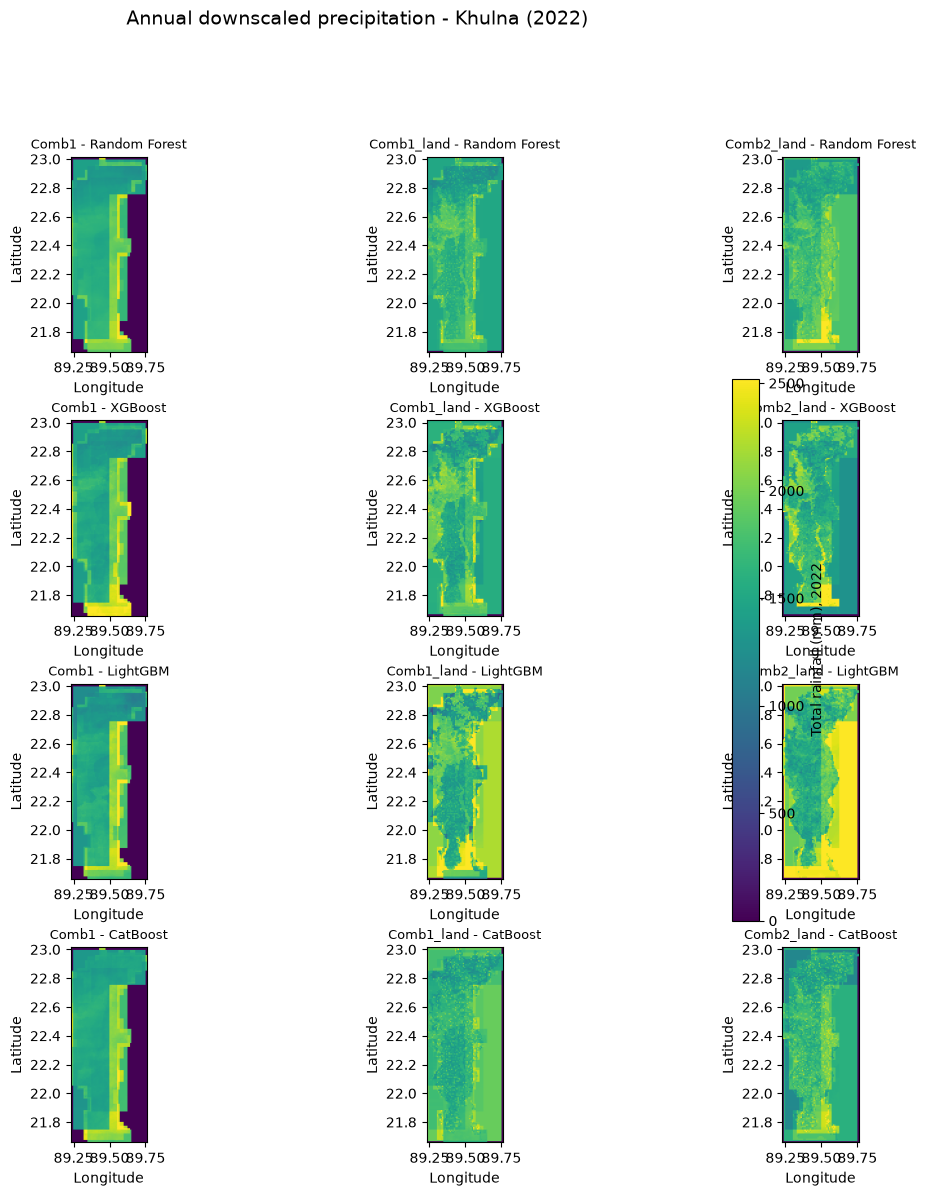

In [11]:
def annual_sum(combo,model_name,year):
    files=sorted((MAP_DIR/combo/model_name.replace(" ","_")).glob(f"downscaled_{year}_*.tif"))
    arrays=[]; bounds=None
    for p in files:
        a,_,b=raster_array(p); arrays.append(a); bounds=b
    if not arrays: return None,None
    return np.nansum(np.stack(arrays),axis=0),bounds

if MAP_COMBOS:
    year=TEST_YEARS[0]
    model_names=[m for m in MODELS if (MAP_COMBOS[0],m) in trained]
    fig,axes=plt.subplots(len(model_names),len(MAP_COMBOS),figsize=(4.4*len(MAP_COMBOS),3.2*len(model_names)),squeeze=False)
    annual_cache={}
    vals=[]
    for m in model_names:
        for c in MAP_COMBOS:
            arr,b=annual_sum(c,m,year); annual_cache[(c,m)]=(arr,b)
            if arr is not None: vals.extend(arr[np.isfinite(arr)].ravel()[::50])
    vmin,vmax=(np.nanpercentile(vals,[2,98]) if len(vals) else (0,1))
    im=None
    for i,m in enumerate(model_names):
        for j,c in enumerate(MAP_COMBOS):
            ax=axes[i,j]; arr,b=annual_cache[(c,m)]
            if arr is None: ax.axis("off"); continue
            im=ax.imshow(arr,extent=[b.left,b.right,b.bottom,b.top],origin="upper",vmin=vmin,vmax=vmax,cmap="viridis")
            ax.set_title(f"{c} - {m}",fontsize=9); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    if im is not None: fig.colorbar(im,ax=axes.ravel().tolist(),shrink=.55,label=f"Total rainfall (mm), {year}")
    fig.suptitle(f"Annual downscaled precipitation - Khulna ({year})",y=.995,fontsize=14)
    fig.subplots_adjust(hspace=.35,wspace=.25,right=.88)
    fig.savefig(FIG_DIR/"Fig_2_annual_rainfall_maps.png",dpi=300,bbox_inches="tight")
    plt.show()


## 9. Figs. 3-5 equivalents - spatial MAE, RMSE and PCC at gauge stations

For each model, metrics are calculated station-by-station over all months in the independent test year(s). The plotted value uses the best available priority combination (`Comb1_land`, then `Comb2_land`, then `Comb1`).

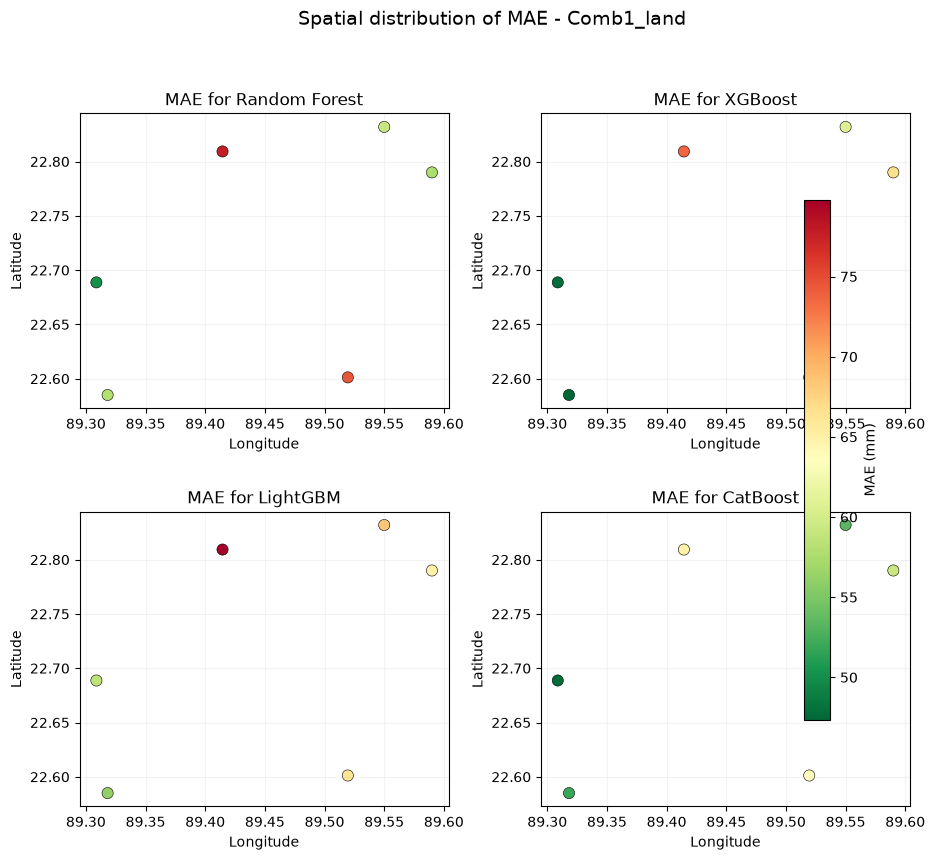

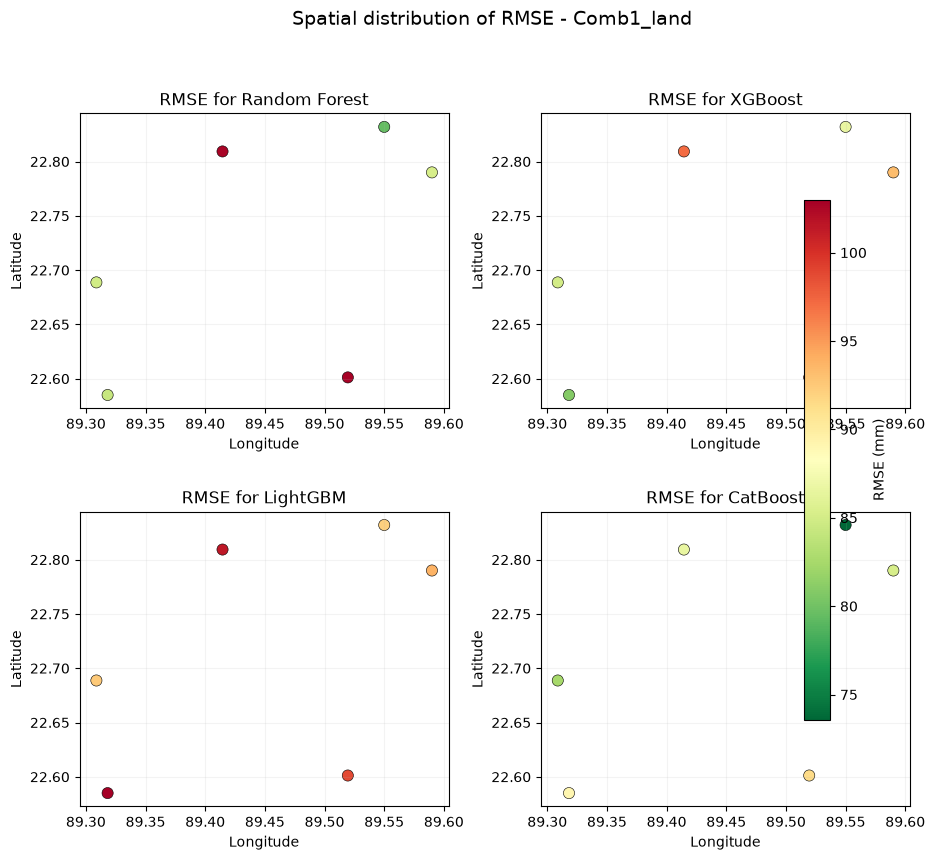

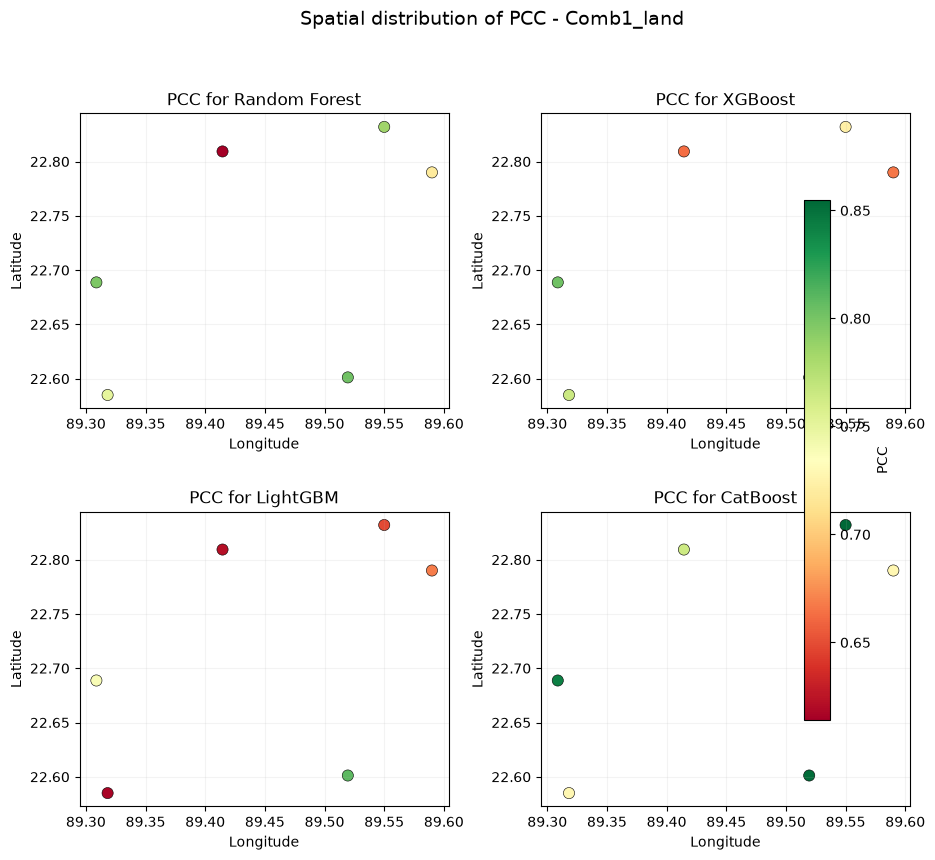

In [12]:
PRIORITY_SPATIAL = next((c for c in ["Comb1_land","Comb2_land","Comb1"] if c in COMBINATIONS), None)

def station_metric_table(combo,model_name):
    b=trained[(combo,model_name)]
    idx=b["test_index"]
    sub=data.loc[idx].copy()
    sub["prediction"]=b["pred_test"]
    group_col="station_id" if "station_id" in sub.columns else ("station" if "station" in sub.columns else None)
    if group_col is None: raise ValueError("Need station_id or station column")
    rec=[]
    for sid,g in sub.groupby(group_col):
        mm=metrics(g[TARGET],g["prediction"])
        rec.append({group_col:sid,"latitude":g.latitude.iloc[0],"longitude":g.longitude.iloc[0],**mm})
    return pd.DataFrame(rec)

spatial_tables={}
if PRIORITY_SPATIAL:
    for m in MODELS:
        if (PRIORITY_SPATIAL,m) in trained:
            spatial_tables[m]=station_metric_table(PRIORITY_SPATIAL,m)
            spatial_tables[m].to_csv(TABLE_DIR/f"station_metrics_{PRIORITY_SPATIAL}_{m.replace(' ','_')}.csv",index=False)

def spatial_metric_figure(metric,cmap,filename):
    names=list(spatial_tables)
    if not names: return
    n=len(names); ncols=2; nrows=math.ceil(n/ncols)
    fig,axes=plt.subplots(nrows,ncols,figsize=(11,4.5*nrows),squeeze=False)
    vals=np.concatenate([t[metric].dropna().to_numpy() for t in spatial_tables.values()])
    vmin,vmax=np.nanpercentile(vals,[2,98]) if len(vals)>1 else (np.nanmin(vals),np.nanmax(vals)+1e-9)
    sc=None
    for ax,name in zip(axes.ravel(),names):
        t=spatial_tables[name]
        sc=ax.scatter(t.longitude,t.latitude,c=t[metric],s=65,edgecolor="black",linewidth=.4,cmap=cmap,vmin=vmin,vmax=vmax)
        ax.set_title(f"{metric} for {name}"); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(alpha=.15)
    for ax in axes.ravel()[len(names):]: ax.axis("off")
    if sc is not None: fig.colorbar(sc,ax=axes.ravel().tolist(),shrink=.75,label=metric + (" (mm)" if metric in {"MAE","RMSE"} else ""))
    fig.suptitle(f"Spatial distribution of {metric} - {PRIORITY_SPATIAL}",y=.995,fontsize=14)
    fig.subplots_adjust(hspace=.35,wspace=.25,right=.88)
    fig.savefig(FIG_DIR/filename,dpi=300,bbox_inches="tight"); plt.show()

spatial_metric_figure("MAE","RdYlGn_r","Fig_3_spatial_MAE.png")
spatial_metric_figure("RMSE","RdYlGn_r","Fig_4_spatial_RMSE.png")
spatial_metric_figure("PCC","RdYlGn","Fig_5_spatial_PCC.png")


## 10. SHAP analysis and Figs. 6-8 equivalents

The paper shows both a SHAP summary (beeswarm) and mean absolute SHAP importance. The functions below generate the same two views for each model and combination pair.

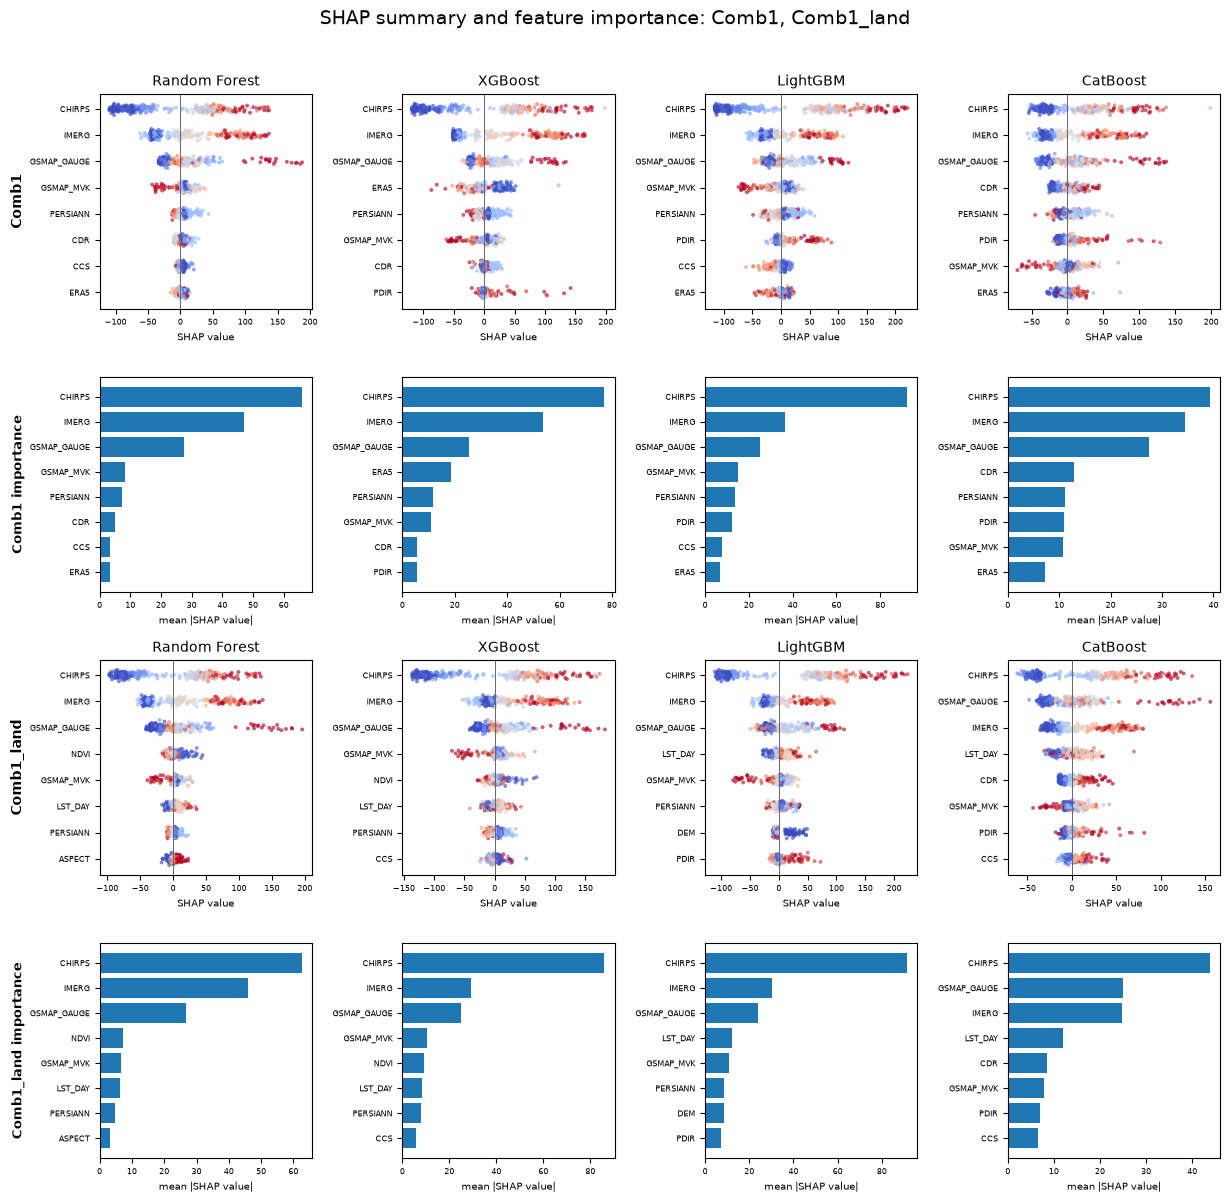

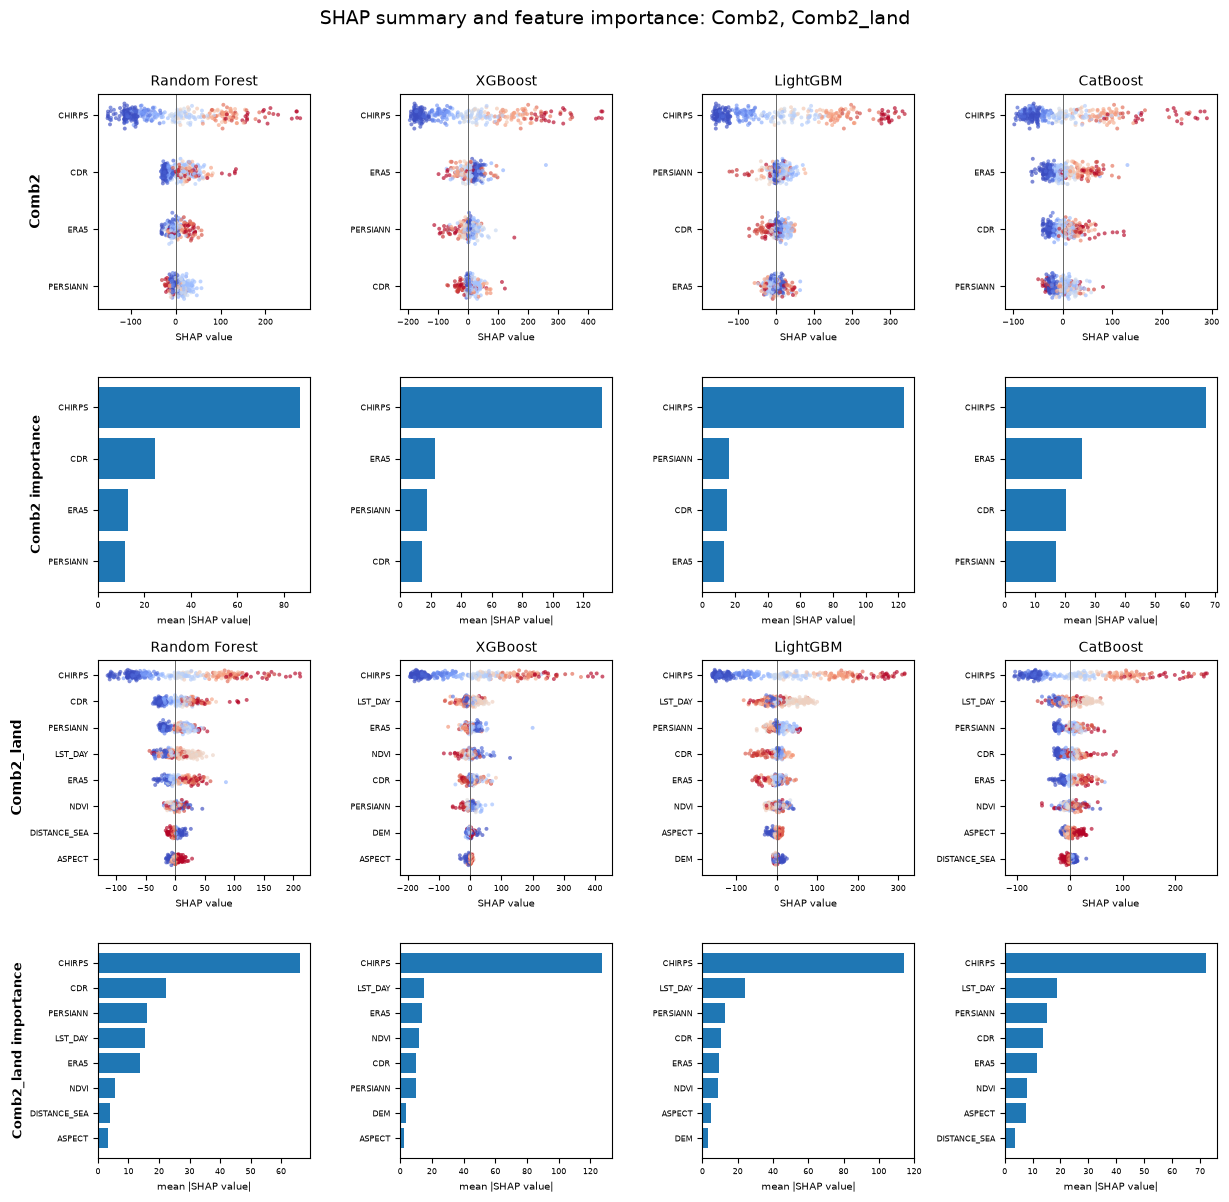

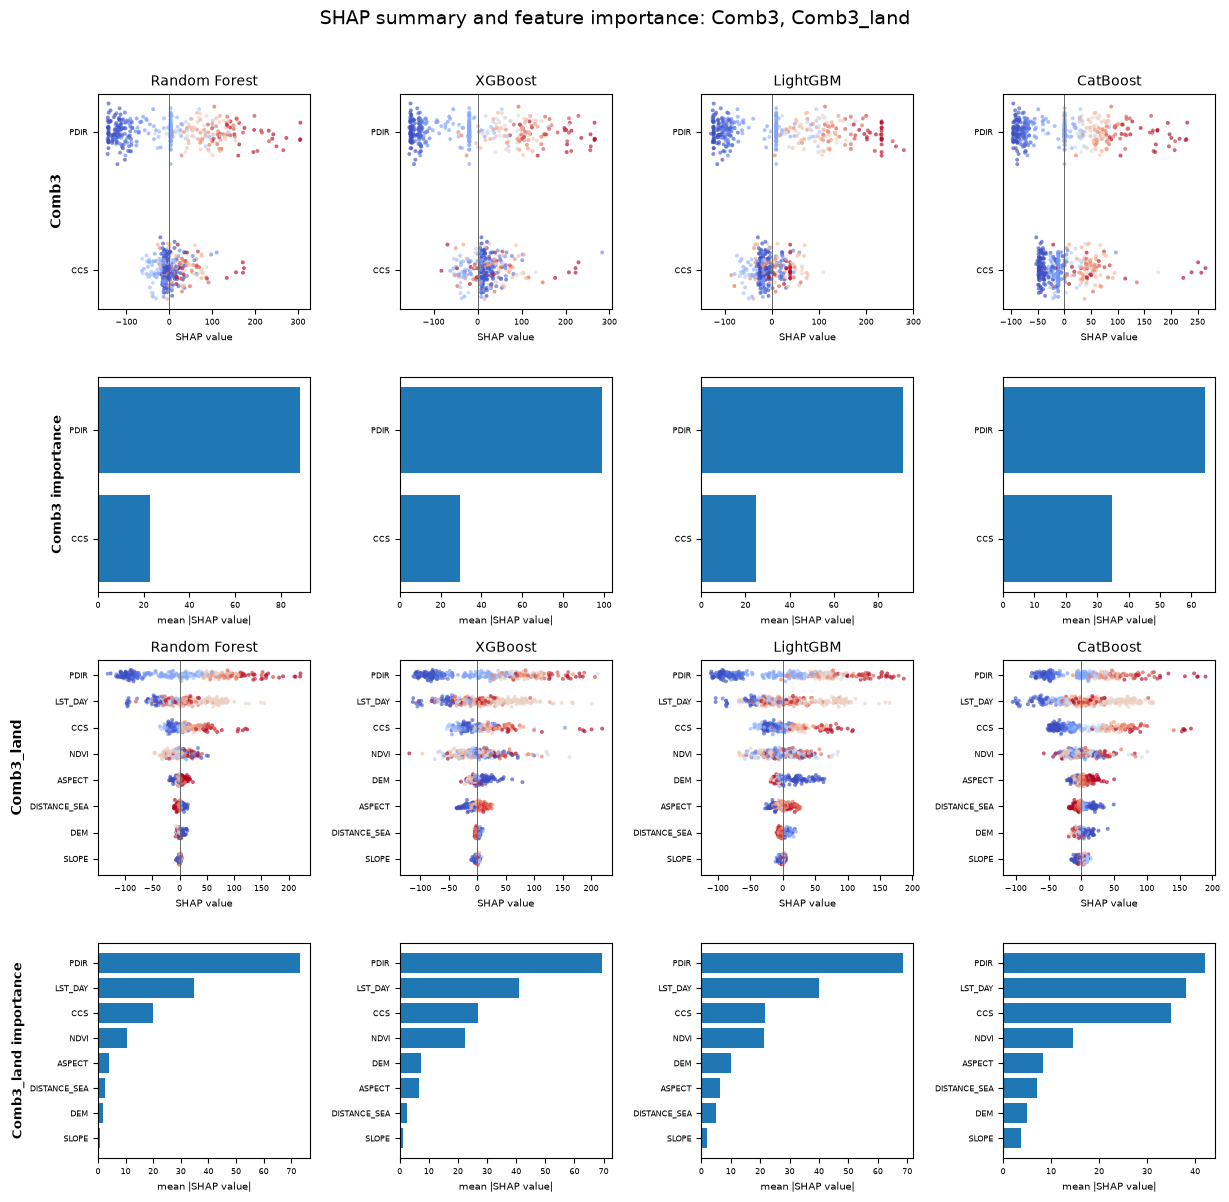

In [13]:
try:
    import shap
    SHAP_OK=True
except Exception as e:
    SHAP_OK=False; print("SHAP unavailable:",e)

def compute_shap(bundle):
    features=bundle["features"]
    dev=data[data.year.isin(TRAIN_YEARS+VALID_YEARS)][features].replace([np.inf,-np.inf],np.nan)
    rng=np.random.default_rng(RANDOM_STATE)
    if len(dev)>MAX_SHAP_SAMPLES:
        dev=dev.iloc[rng.choice(len(dev),MAX_SHAP_SAMPLES,replace=False)]
    X=bundle["imputer"].transform(dev)
    est=bundle["estimator"]
    # TreeExplainer first; generic Explainer is fallback for Cubist/other models.
    try:
        exp=shap.TreeExplainer(est)
        sv=exp.shap_values(X)
        if isinstance(sv,list): sv=sv[0]
    except Exception:
        bg=X[:min(80,len(X))]
        exp=shap.Explainer(est.predict,bg)
        sv=exp(X, max_evals=max(2*X.shape[1]+1,101)).values
    return np.asarray(sv), X, features

def draw_beeswarm(ax,sv,X,features,top_n=8):
    imp=np.mean(np.abs(sv),axis=0); order=np.argsort(imp)[-top_n:][::-1]
    rng=np.random.default_rng(42)
    for rank,j in enumerate(order):
        vals=sv[:,j]; feat=X[:,j]
        finite=np.isfinite(feat)
        if finite.any():
            lo,hi=np.nanpercentile(feat[finite],[5,95]); den=max(hi-lo,1e-9); color=np.clip((feat-lo)/den,0,1)
        else: color=np.zeros(len(feat))
        y=rank+rng.normal(0,.08,size=len(vals))
        ax.scatter(vals,y,c=color,cmap="coolwarm",s=8,alpha=.65,edgecolors="none")
    ax.axvline(0,color="0.4",lw=.7); ax.set_yticks(range(len(order))); ax.set_yticklabels([features[j] for j in order],fontsize=7)
    ax.invert_yaxis(); ax.set_xlabel("SHAP value",fontsize=7); ax.tick_params(labelsize=6)

def draw_importance(ax,sv,features,top_n=8):
    imp=np.mean(np.abs(sv),axis=0); order=np.argsort(imp)[-top_n:]
    ax.barh(range(len(order)),imp[order]); ax.set_yticks(range(len(order))); ax.set_yticklabels([features[j] for j in order],fontsize=7)
    ax.set_xlabel("mean |SHAP value|",fontsize=7); ax.tick_params(labelsize=6)

def shap_pair_figure(combo_a,combo_b,filename):
    pairs=[c for c in [combo_a,combo_b] if c in COMBINATIONS]
    model_names=[m for m in MODELS if all((c,m) in trained for c in pairs)]
    if not SHAP_OK or not pairs or not model_names: return
    fig,axes=plt.subplots(2*len(pairs),len(model_names),figsize=(3.1*len(model_names),3.0*2*len(pairs)),squeeze=False)
    for block,c in enumerate(pairs):
        for j,m in enumerate(model_names):
            try:
                sv,X,feat=compute_shap(trained[(c,m)])
                draw_beeswarm(axes[2*block,j],sv,X,feat)
                draw_importance(axes[2*block+1,j],sv,feat)
                axes[2*block,j].set_title(m,fontsize=10)
                if j==0:
                    axes[2*block,j].set_ylabel(c,fontsize=10,fontweight="bold")
                    axes[2*block+1,j].set_ylabel(c+" importance",fontsize=9,fontweight="bold")
            except Exception as e:
                axes[2*block,j].text(.5,.5,f"SHAP failed\n{e}",ha="center",va="center",transform=axes[2*block,j].transAxes,fontsize=7)
                axes[2*block+1,j].axis("off")
    fig.suptitle(f"SHAP summary and feature importance: {', '.join(pairs)}",y=.998,fontsize=14)
    fig.tight_layout(rect=[0,0,1,.985])
    fig.savefig(FIG_DIR/filename,dpi=300,bbox_inches="tight"); plt.show()

shap_pair_figure("Comb1","Comb1_land","Fig_6_SHAP_Comb1_Comb1_land.png")
shap_pair_figure("Comb2","Comb2_land","Fig_7_SHAP_Comb2_Comb2_land.png")
shap_pair_figure("Comb3","Comb3_land","Fig_8_SHAP_Comb3_Comb3_land.png")


## 11. Observed vs predicted and best-model summary

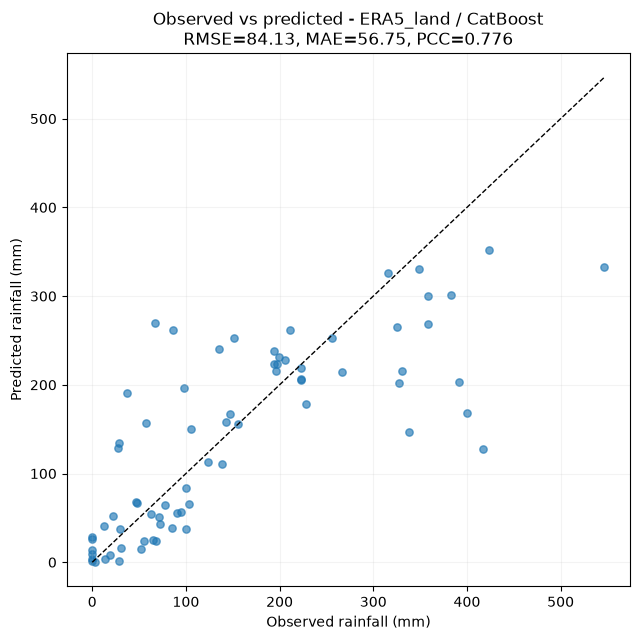

Best independent-test result:


,value
Input,ERA5_land
Model,CatBoost
MAE,56.754988
RMSE,84.134449
PCC,0.77646
BestParams,"{""depth"": 7, ""iterations"": 300, ""learning_rate..."


In [14]:
if not results_long.empty:
    best_row=results_long.sort_values(["RMSE","MAE"],ascending=[True,True]).iloc[0]
    best_key=(best_row.Input,best_row.Model)
    b=trained[best_key]
    fig,ax=plt.subplots(figsize=(6.5,6.5))
    ax.scatter(b["y_test"],b["pred_test"],alpha=.65,s=28)
    lo=min(np.min(b["y_test"]),np.min(b["pred_test"])); hi=max(np.max(b["y_test"]),np.max(b["pred_test"]))
    ax.plot([lo,hi],[lo,hi],"--",lw=1,color="black")
    ax.set_xlabel("Observed rainfall (mm)"); ax.set_ylabel("Predicted rainfall (mm)")
    ax.set_title(f"Observed vs predicted - {best_row.Input} / {best_row.Model}\nRMSE={best_row.RMSE:.2f}, MAE={best_row.MAE:.2f}, PCC={best_row.PCC:.3f}")
    ax.grid(alpha=.15); fig.tight_layout(); fig.savefig(FIG_DIR/"observed_vs_predicted_best.png",dpi=300); plt.show()
    print("Best independent-test result:")
    display(best_row.to_frame("value"))


## 12. Export manifest

This final cell lists the generated paper-style outputs. If any model package is missing, install it and rerun from the model cell.

In [15]:
manifest=[]
for folder in [TABLE_DIR,FIG_DIR,MAP_DIR,MODEL_DIR]:
    for p in sorted(folder.rglob("*")):
        if p.is_file(): manifest.append(str(p.relative_to(PROJECT_ROOT)))
manifest_df=pd.DataFrame({"output":manifest})
manifest_df.to_csv(OUT_ROOT/"output_manifest.csv",index=False)
display(manifest_df)
print("Done. Main output folder:",OUT_ROOT)


,output
0,outputs\paper_style\tables\input_combinations.csv
1,outputs\paper_style\tables\station_metrics_Com...
2,outputs\paper_style\tables\station_metrics_Com...
3,outputs\paper_style\tables\station_metrics_Com...
4,outputs\paper_style\tables\station_metrics_Com...
...,...
154,outputs\paper_style\maps\Comb2_land\XGBoost\do...
155,outputs\paper_style\maps\Comb2_land\XGBoost\do...
156,outputs\paper_style\maps\Comb2_land\XGBoost\do...
157,outputs\paper_style\maps\Comb2_land\XGBoost\do...


Done. Main output folder: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style
